Aperçu des données :
         id diagnosis  radius_mean  texture_mean  perimeter_mean  area_mean  \
0    842302         M        17.99         10.38          122.80     1001.0   
1    842517         M        20.57         17.77          132.90     1326.0   
2  84300903         M        19.69         21.25          130.00     1203.0   
3  84348301         M        11.42         20.38           77.58      386.1   
4  84358402         M        20.29         14.34          135.10     1297.0   

   smoothness_mean  compactness_mean  concavity_mean  concave points_mean  \
0          0.11840           0.27760          0.3001              0.14710   
1          0.08474           0.07864          0.0869              0.07017   
2          0.10960           0.15990          0.1974              0.12790   
3          0.14250           0.28390          0.2414              0.10520   
4          0.10030           0.13280          0.1980              0.10430   

   ...  texture_worst  perimeter_worst  a

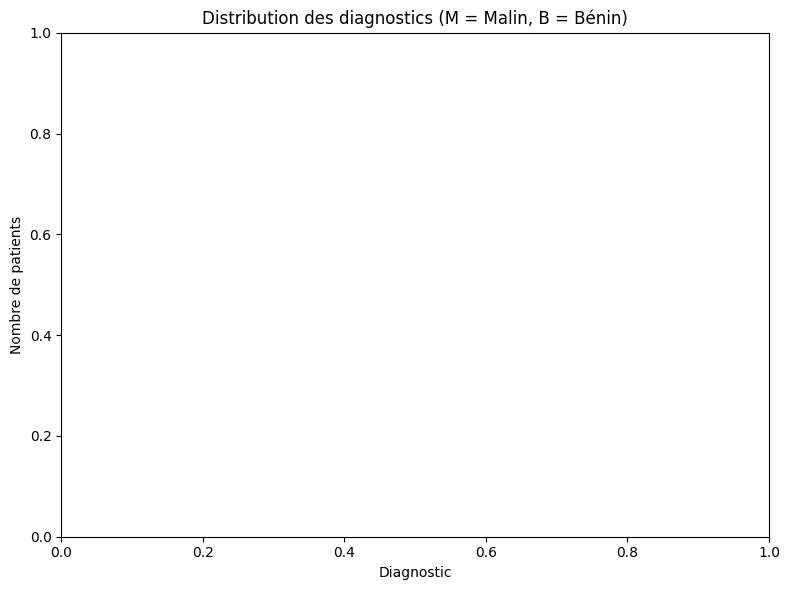


Comptage des valeurs uniques dans 'diagnosis' :
Series([], Name: count, dtype: int64)

Après mapping (1 = Malin, 0 = Bénin) :
Series([], Name: diagnosis, dtype: int64)

Vérification des valeurs infinies :
diagnosis                  0
radius_mean                0
texture_mean               0
perimeter_mean             0
area_mean                  0
smoothness_mean            0
compactness_mean           0
concavity_mean             0
concave points_mean        0
symmetry_mean              0
fractal_dimension_mean     0
radius_se                  0
texture_se                 0
perimeter_se               0
area_se                    0
smoothness_se              0
compactness_se             0
concavity_se               0
concave points_se          0
symmetry_se                0
fractal_dimension_se       0
radius_worst               0
texture_worst              0
perimeter_worst            0
area_worst                 0
smoothness_worst           0
compactness_worst          0
concavity_w

ValueError: With n_samples=0, test_size=0.2 and train_size=None, the resulting train set will be empty. Adjust any of the aforementioned parameters.

In [9]:
# Importation des bibliothèques
import os
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.neighbors import KNeighborsClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.svm import SVC
from sklearn.metrics import accuracy_score
from sklearn.preprocessing import LabelEncoder

# Chargement du dataset local
file_path = "data.csv"
if not os.path.exists(file_path):
    raise FileNotFoundError(f"Le fichier de données '{file_path}' est introuvable. Vérifiez qu'il est présent dans le dossier {os.getcwd()}.")

df = pd.read_csv(file_path)

# Aperçu des données
print("Aperçu des données :")
print(df.head())
print("\nInformations sur le dataset :")
print(df.info())

# Vérification des valeurs manquantes
print("\nValeurs manquantes par colonne :")
print(df.isnull().sum())

# Suppression des lignes avec des valeurs manquantes
df = df.dropna()
print(f"\nNombre de lignes après suppression des NaN : {len(df)}")

# Suppression de la colonne 'id' si elle existe
if 'id' in df.columns:
    df = df.drop('id', axis=1)
print("\nColonnes après suppression de 'id' :")
print(df.columns.tolist())

# Vérification des types de données
print("\nTypes de données des colonnes :")
print(df.dtypes)

# Conversion de toutes les colonnes numériques en float
for col in df.columns:
    if col != 'diagnosis':
        df[col] = pd.to_numeric(df[col], errors='coerce')

# Suppression des lignes avec des valeurs NaN après conversion
df = df.dropna()
print(f"\nNombre de lignes après conversion et nettoyage : {len(df)}")

# Countplot pour visualiser la distribution du diagnostic
plt.figure(figsize=(8, 6))
sns.countplot(data=df, x='diagnosis', palette='magma')
plt.title('Distribution des diagnostics (M = Malin, B = Bénin)')
plt.xlabel('Diagnostic')
plt.ylabel('Nombre de patients')
plt.tight_layout()
plt.show()

# Comptage des valeurs uniques dans 'diagnosis'
print("\nComptage des valeurs uniques dans 'diagnosis' :")
print(df['diagnosis'].value_counts())

# Mapping des valeurs catégorielles en valeurs numériques
df['diagnosis'] = df['diagnosis'].map({'M': 1, 'B': 0})
print("\nAprès mapping (1 = Malin, 0 = Bénin) :")
print(df['diagnosis'].head())

# Vérification des valeurs infinies
print("\nVérification des valeurs infinies :")
print(np.isinf(df.select_dtypes(include=[np.number])).sum())

# Séparation des features et de la cible
X = df.drop('diagnosis', axis=1)
y = df['diagnosis']

# Vérification que X ne contient que des données numériques
print(f"\nNombre de colonnes dans X : {X.shape[1]}")
print(f"Types de données dans X :\n{X.dtypes.value_counts()}")

# Division en ensemble d'entraînement et de test
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

print(f"\nTaille de l'ensemble d'entraînement : {X_train.shape}")
print(f"Taille de l'ensemble de test : {X_test.shape}")

# Modèle 1: Régression Logistique
logreg = LogisticRegression(max_iter=1000)
logreg.fit(X_train, y_train)
y_pred_logreg = logreg.predict(X_test)
acc_logreg = accuracy_score(y_test, y_pred_logreg)
print(f"\nPrécision - Régression Logistique : {acc_logreg:.4f} ({acc_logreg*100:.2f}%)")

# Modèle 2: K Plus Proches Voisins (KNN)
knn = KNeighborsClassifier(n_neighbors=5)
knn.fit(X_train, y_train)
y_pred_knn = knn.predict(X_test)
acc_knn = accuracy_score(y_test, y_pred_knn)
print(f"Précision - KNN : {acc_knn:.4f} ({acc_knn*100:.2f}%)")

# Modèle 3: Forêts Aléatoires (Random Forests)
rf = RandomForestClassifier(n_estimators=100, random_state=42)
rf.fit(X_train, y_train)
y_pred_rf = rf.predict(X_test)
acc_rf = accuracy_score(y_test, y_pred_rf)
print(f"Précision - Random Forests : {acc_rf:.4f} ({acc_rf*100:.2f}%)")

# Modèle 4: Support Vector Machines (SVM)
svm = SVC(kernel='rbf', random_state=42)
svm.fit(X_train, y_train)
y_pred_svm = svm.predict(X_test)
acc_svm = accuracy_score(y_test, y_pred_svm)
print(f"Précision - SVM : {acc_svm:.4f} ({acc_svm*100:.2f}%)")

# Comparaison des modèles
models = ['Logistic Regression', 'KNN', 'Random Forests', 'SVM']
accuracies = [acc_logreg, acc_knn, acc_rf, acc_svm]

plt.figure(figsize=(10, 6))
plt.bar(models, accuracies, color=['blue', 'green', 'orange', 'purple'])
plt.ylim(0.9, 1.0)
plt.ylabel('Précision')
plt.title('Comparaison des modèles de classification')
plt.axhline(y=max(accuracies), color='red', linestyle='--', label=f'Meilleur : {max(accuracies):.4f}')
plt.legend()
plt.tight_layout()
plt.show()

# Détermination du meilleur modèle
best_model_index = accuracies.index(max(accuracies))
best_model_name = models[best_model_index]
print(f"\n🏆 Le meilleur modèle est : {best_model_name} avec une précision de {max(accuracies):.4f} ({max(accuracies)*100:.2f}%)")

print("\n--- INTERPRÉTATION DES RÉSULTATS ---")
print("Tous les modèles montrent d'excellentes performances (> 95%).")
print("Le modèle Random Forests semble particulièrement adapté car il gère bien")
print("les interactions entre les caractéristiques et est robuste au bruit.")
print("La régression logistique est plus rapide et plus interprétable,")
print("mais peut être moins performante sur des données complexes.")